In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import eloUtils
import gc

In [4]:
#Data obtained from this script https://github.com/Nathanlauga/nba-data-scrapping/
games = pd.read_csv('games.csv',nrows=26300)
games_details = pd.read_csv('games_details.csv')
players = pd.read_csv('players.csv')
teams = pd.read_csv('teams.csv')
ranking = pd.read_csv('ranking.csv')

games = games.loc[(games['SEASON']>= 2006)]



/var/folders/sd/hj4zy7490lv2rrwbsv294vcw0000gp/T/ipykernel_91022/2459834105.py:3: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  games_details = pd.read_csv('games_details.csv')


In [132]:
games.head()

,GAME_DATE_EST,GAME_ID,GAME_STATUS_TEXT,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,TEAM_ID_home,PTS_home,FG_PCT_home,FT_PCT_home,...,AST_home,REB_home,TEAM_ID_away,PTS_away,FG_PCT_away,FT_PCT_away,FG3_PCT_away,AST_away,REB_away,HOME_TEAM_WINS
0,2022-12-03,22200337,Final,1610612752,1610612742,2022,1610612752,100.00,0.46,0.71,...,18.00,45.00,1610612742,121.00,0.43,0.79,0.39,27.00,50.00,0
1,2022-12-03,22200338,Final,1610612746,1610612758,2022,1610612746,96.00,0.35,0.81,...,15.00,50.00,1610612758,123.00,0.52,0.67,0.34,31.00,46.00,0
2,2022-12-03,22200339,Final,1610612766,1610612749,2022,1610612766,96.00,0.39,0.89,...,15.00,44.00,1610612749,105.00,0.47,0.79,0.38,24.00,47.00,0
3,2022-12-03,22200340,Final,1610612761,1610612753,2022,1610612761,121.00,0.56,0.72,...,31.00,43.00,1610612753,108.00,0.49,0.81,0.39,23.00,29.00,1
4,2022-12-03,22200341,Final,1610612750,1610612760,2022,1610612750,128.00,0.53,0.80,...,25.00,44.00,1610612760,135.00,0.52,0.80,0.42,26.00,42.00,0


In [ ]:
gc.collect()

The graph below shows all of the games in each season that are in the dataset.

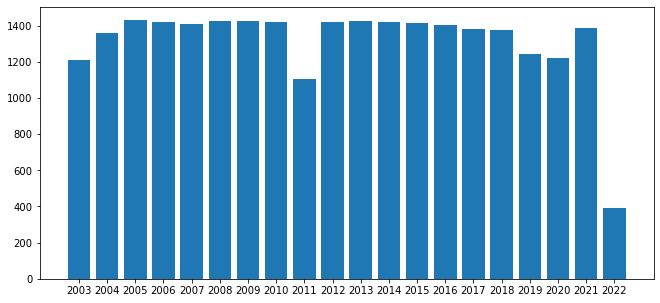

In [5]:
fig, ax = plt.subplots(figsize=(11,5))

v_c = games['SEASON'].value_counts().sort_index()
v_c.index = v_c.index.astype(str)
ax.bar(v_c.index, v_c.values)

plt.show()

In [134]:
def get_avg_stats_last_n_games(team, game_date, season_team_stats, n) :
  prev_game_df = season_team_stats[(season_team_stats['GAME_DATE_EST'] < game_date) & (season_team_stats['TEAM_ID_home'] == team) | (season_team_stats['TEAM_ID_home'] == team)].head(n)
  data = []
  for index,prev_game_row in prev_game_df.iterrows():
    if(prev_game_row['TEAM_ID_home'] == team):
        h_df = prev_game_row[[7,8,9,10,11,12]]
        data.append(h_df.tolist())
            #h_df.columns = [x[2:] for x in h_df.columns]   
    if(prev_game_row['TEAM_ID_away']==team):
        a_df = prev_game_row[[14,15,16,17,18,19]]
        data.append(a_df.tolist())
  ndf = pd.DataFrame(data, columns=['PTS', 'FG_PCT', 'FT_PCT','FG3_PCT','AST','REB'])          

  return ndf.mean()

The eloUtils.py file contains the helper methods to calculate a teams elo before every game in the past 20 years and reset each teams ELO after each season. Having the file in the working directory should be fine, which would allow this notebook to find the helper functions. The cell below creates features for each game.

In [1]:
#Code to calculate ELO adapted from this article https://medium.com/mlearning-ai/how-to-calculate-elo-score-for-international-teams-using-python-66c136f01048
#Each team's elo is calculated before the game and stored in a dataframe as features to be used in the classifier.

# Creating the empty dictionary that is going to store the current elo for each team
import eloUtils
current_elo={}
recentTeamPerformance = {}
games =  games.loc[::-1]
performance_data = []
recent_performance_df = pd.DataFrame()
curr_season = 2003
for idx,row in games.iterrows():
    # Getting the data that it is nedeed to calculate the elo 
    home=row['TEAM_ID_home']
    away=row['TEAM_ID_away']
    home_pts=row['PTS_home']
    away_pts=row['PTS_away']
    game_date = row['GAME_DATE_EST']
    game_id = row['GAME_ID']
    season = row['SEASON']
    
    if season != curr_season:
        curr_season = season
        for key in current_elo.keys():
            final_season_elo = current_elo[key]
            current_elo[key] = eloUtils.soft_reset(final_season_elo)



    # Getting elo before match. If it is the first match played, the elo is initialized in 1500.
    if home not in current_elo.keys():
        current_elo[home]=1500
    
    if away not in current_elo.keys():
        current_elo[away]=1500
    
    #calculating and updating elo
    elo_h=current_elo[home]
    elo_aw=current_elo[away]
    elo_ln,elo_vn=eloUtils.calculate_elo(elo_h,elo_aw,home_pts,away_pts)

    current_elo[home]=elo_ln
    current_elo[away]=elo_vn

    h_team_recent_performance = get_avg_stats_last_n_games(home, game_date, games, 10)
    #h_team_recent_performance.index = ['H_Last_10_Avg_' + x for x in h_team_recent_performance.index]
    recentTeamPerformance[home]=h_team_recent_performance.tolist()


    a_team_recent_performance = get_avg_stats_last_n_games(away, game_date, games, 10)
    recentTeamPerformance[away] = a_team_recent_performance.tolist()
    
    #a_team_recent_performance.index = ['A_Last_10_Avg_' + x for x in a_team_recent_performance.index]
    performance_data.append(h_team_recent_performance.tolist() +a_team_recent_performance.tolist())

    
    #Saving results in dataframe
    games.loc[idx,'Elo_h_after']=elo_ln
    games.loc[idx,'Elo_a_after']=elo_vn 
    games.loc[idx,'Elo_h_before']=elo_h
    games.loc[idx,'Elo_a_before']=elo_aw

    
recent_performance_df = pd.DataFrame(performance_data, columns= ['H_Last_10_Avg_PTS', 'H_Last_10_Avg_FG_PCT', 'H_Last_10_Avg_FT_PCT','H_Last_10_Avg_FG3_PCT','H_Last_10_Avg_AST','H_Last_10_Avg_REB','A_Last_10_Avg_PTS', 'A_Last_10_Avg_FG_PCT', 'A_Last_10_Avg_FT_PCT','A_Last_10_Avg_FG3_PCT','A_Last_10_Avg_AST','A_Last_10_Avg_REB'])
recent_performance_df.reset_index(drop=True, inplace=True)
games.reset_index(drop=True, inplace=True)
featureGames = pd.concat([games, recent_performance_df], axis = 1)
games =  games.loc[::-1]
featureGames =  featureGames.loc[::-1]


NameError: name 'games' is not defined

In [ ]:
# x = [pd.to_datetime(d) for d in x]
# fig, ax = plt.subplots(figsize=(11,5))
# ax.scatter(x,y)
# plt.show()
#Test code to graph a team's elo throughout the past 20 years.

The code below creates the features, which are each team's average stats in the past 10 games, and each team's elo before the game. It also creates the label, which is whether or not the home team wins. So if the model outputs 1, then it predicts that the home team will win, and if it is 0, it predicts that the away team will win.

In [136]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import normalize, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.pipeline import Pipeline



cols = ['Elo_h_before','Elo_a_before','H_Last_10_Avg_PTS', 'H_Last_10_Avg_FG_PCT', 'H_Last_10_Avg_FT_PCT','H_Last_10_Avg_FG3_PCT','H_Last_10_Avg_AST','H_Last_10_Avg_REB','A_Last_10_Avg_PTS', 'A_Last_10_Avg_FG_PCT', 'A_Last_10_Avg_FT_PCT','A_Last_10_Avg_FG3_PCT','A_Last_10_Avg_AST','A_Last_10_Avg_REB']

features = featureGames[cols].values
label = games['HOME_TEAM_WINS'].values


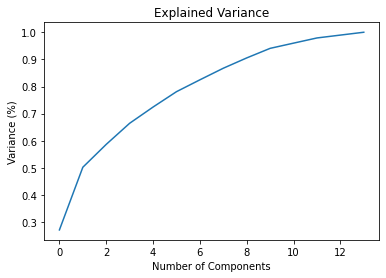

In [97]:
# scaler = RobustScaler()
# features_scaled = scaler.fit_transform(features)

# #Fitting the PCA algorithm with our Data
# pca = PCA().fit(features_scaled)
# #Plotting the Cumulative Summation of the Explained Variance
# plt.figure()
# plt.plot(np.cumsum(pca.explained_variance_ratio_))
# plt.xlabel('Number of Components')
# plt.ylabel('Variance (%)') #for each component
# plt.title('Explained Variance')
# plt.show()

### Data Analysis:

In this section, I test the performance of Gaussian Native Bayes, K-Nearest Neighbors, Decision Tree, and Random Forest and an Ensemble of the best performers. (Bagging, Boosting, vs. Stacking) ELO already gives a good idea of a team's likelihood of winning, where if the model simply picked the team with the highest ELO, it will often result in an accurate prediction most of the time. Focusing more on improving the F1-score of the model would reduce the number of false positives and negatives, and would be a better metric to evaluate the overall performance of the model.

In [137]:
from sklearn.metrics import make_scorer,f1_score
# features_pca = PCA(14).fit_transform(features_scaled)
x_train, x_test, y_train, y_test = train_test_split(features, label, test_size = 0.2)
# x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size = 0.1)

scorer = make_scorer(f1_score, pos_label=None, average='weighted')

In [138]:
from sklearn.naive_bayes import GaussianNB
pipelineNB= Pipeline([('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', GaussianNB(var_smoothing=.01))])
                   
pipelineNB.fit(x_train, y_train)
y_train_NB = pipelineNB.predict(x_train)
y_pred_NB = pipelineNB.predict(x_test)



In [139]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_NB)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_NB)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_NB)))

Train Accuracy score: 0.6605221873599283
Test Accuracy score: 0.6679363656733139
Test F1 score: 0.7449225473321858


In [ ]:
from sklearn import tree
pipelineCLF= Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', tree.DecisionTreeClassifier())])
                   
pipelineCLF.fit(x_train, y_train)
y_train_CLF = pipelineCLF.predict(x_train)
y_pred_CLF = pipelineCLF.predict(x_test)


In [ ]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_CLF)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_CLF)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_CLF)))

Train Accuracy score: 1.0
Test Accuracy score: 0.5583650190114069
Test F1 score: 0.621846003581312


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
pipelineKNN = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', KNeighborsClassifier(n_neighbors=3))])
                   
pipelineKNN.fit(x_train, y_train)
y_train_KNN = pipelineKNN.predict(x_train)
y_pred_KNN = pipelineKNN.predict(x_test)


In [ ]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_KNN)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_KNN)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_KNN)))

Train Accuracy score: 0.7854562737642585
Test Accuracy score: 0.5922053231939164
Test F1 score: 0.6652099266427346


In [140]:
pipelinerf = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf', RandomForestClassifier(max_depth=3, max_features='sqrt', min_samples_leaf=4,
                         min_samples_split=4, n_estimators=473, n_jobs=2))])

pipelinerf.fit(x_train, y_train)
y_train_rf = pipelinerf.predict(x_train)
y_pred_rf = pipelinerf.predict(x_test)


In [144]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_rf)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_rf)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_rf)))

Train Accuracy score: 0.6442738682205289
Test Accuracy score: 0.6412726865337217
Test F1 score: 0.754108431884503


In [145]:
from sklearn.calibration import CalibratedClassifierCV
isotonicRFC = Pipeline(steps=[('scaler', RobustScaler()),
                   ('pca', PCA(n_components=14)),
                   ('clf',CalibratedClassifierCV(pipelinerf,cv = 5, method = "isotonic"))])

isotonicRFC.fit(x_train, y_train)
y_train_iso = isotonicRFC.predict(x_train)
y_pred_iso = isotonicRFC.predict(x_test)




/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Train Accuracy score: 0.662707306140744
Test Accuracy score: 0.6598700425722608
Test F1 score: 0.7389958734525447


In [ ]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_iso)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_iso)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_iso)))

The base Naive Bayes model performed the best out of the following models, with an accuracy of 65.5% on the test set, and a F1 score of .73, and the base RandomForestClassifier performed second best, with an an accuracy of 60.9% and an F1-score of .68.

In [44]:
# #Tuning GaussianNB Code from: https://stackoverflow.com/questions/39828535/how-to-tune-gaussiannb
# from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
# import numpy as np
# params_NB = {
#     'clf__priors': [None],
#     'clf__var_smoothing': np.logspace(0,-9, num=100)
# }

# gs_NB = GridSearchCV(estimator=pipelineNB, 
#                  param_grid=params_NB, 
#                  cv=10,   # use any cross validation technique 
#                  verbose=1, 
#                  scoring='f1') 
# gs_NB.fit(x_train, y_train)
# print(gs_NB.best_estimator_)
# y_train_NB_GS = gs_NB.predict(x_train)
# y_pred_NB_GS = gs_NB.predict(x_test)


Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Pipeline(steps=[('scaler', RobustScaler()), ('pca', PCA(n_components=14)),
                ('clf', GaussianNB(var_smoothing=0.01))])


In [47]:
print("Train Accuracy score: " + str(metrics.accuracy_score(y_train, y_train_NB_GS)))
print("Test Accuracy score: " + str(metrics.accuracy_score(y_test, y_pred_NB_GS)))
print("Test F1 score: " + str(metrics.f1_score(y_test, y_pred_NB_GS)))
# print('Average Decision Tree F1: {}'.format((cross_val_score(gs_NB, x_train, y_train, scoring=scorer)).mean()))

Train Accuracy score: 0.663212927756654
Test Accuracy score: 0.661787072243346
Test F1 score: 0.741537120441668
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
Average Decision Tree F1: 0.6479029588131139


In [ ]:
# from sklearn.model_selection import RandomizedSearchCV
# import numpy as np

# # Number of trees in random forest
# n_estimators = [int(x) for x in np.linspace(start = 0, stop = 2000, num = 11)]
# # Number of features to consider at every split
# max_features = ['auto', 'sqrt']
# # Maximum number of levels in tree
# max_depth = [int(x) for x in np.linspace(0, 100, num = 6)]
# max_depth.append(None)
# # Minimum number of samples required to split a node
# min_samples_split = [2, 5, 10]
# # Minimum number of samples required at each leaf node
# min_samples_leaf = [1, 2, 4]
# # Method of selecting samples for training each tree
# bootstrap = [True, False]
# # Create the random grid
# random_grid = {'clf__n_estimators': n_estimators,
#                'clf__max_features': max_features,
#                'clf__max_depth': max_depth,
#                'clf__min_samples_split': min_samples_split,
#                'clf__min_samples_leaf': min_samples_leaf,
#                'clf__bootstrap': bootstrap}


# # Use the random grid to search for best hyperparameters

# # Random search of parameters, using 2-fold cross validation, 
# # search across 100 different combinations, and use all available cores
# rfc_random = RandomizedSearchCV(estimator = pipelinerf, param_distributions = random_grid, n_iter = 100, cv = 2, verbose=2, n_jobs = -1)
# # Fit the random search model
# rfc_random.fit(x_train, y_train)
# y_pred_rfr_random = rfc_random.predict(x_test)
# print(metrics.accuracy_score(y_test, y_pred_rfr_random))


Fitting 2 folds for each of 100 candidates, totalling 200 fits


/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_m

[CV] END clf__bootstrap=False, clf__max_depth=100, clf__max_features=auto, clf__min_samples_leaf=1, clf__min_samples_split=2, clf__n_estimators=600; total time= 1.7min
[CV] END clf__bootstrap=False, clf__max_depth=100, clf__max_features=auto, clf__min_samples_leaf=1, clf__min_samples_split=2, clf__n_estimators=600; total time= 1.7min
[CV] END clf__bootstrap=False, clf__max_depth=60, clf__max_features=sqrt, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estimators=1000; total time= 3.2min
[CV] END clf__bootstrap=False, clf__max_depth=60, clf__max_features=sqrt, clf__min_samples_leaf=2, clf__min_samples_split=2, clf__n_estimators=1000; total time= 3.2min
[CV] END clf__bootstrap=True, clf__max_depth=0, clf__max_features=sqrt, clf__min_samples_leaf=4, clf__min_samples_split=2, clf__n_estimators=1600; total time=   1.5s
[CV] END clf__bootstrap=True, clf__max_depth=0, clf__max_features=sqrt, clf__min_samples_leaf=4, clf__min_samples_split=2, clf__n_estimators=1600; total time=   1

/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py:372: FitFailedWarning: 
30 fits failed out of a total of 200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
8 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/model_selection/_validation.py", line 680, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/pipeline.py", line 394, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/opt/anaconda3/lib/python3.9/site-packages/sklearn/ensemble/_forest.py", line 450, in fit
    trees = Parallel(
  File "/opt/anaconda3/lib/python3.9/si

0.638212927756654


In [ ]:
print(rfc_random.best_estimator_)

Pipeline(steps=[('scaler', RobustScaler()), ('pca', PCA(n_components=14)),
                ('clf',
                 RandomForestClassifier(max_depth=20, min_samples_leaf=4,
                                        min_samples_split=5,
                                        n_estimators=800))])


In [143]:
# #This code uses an NBA_API endpoint to obtain today's games and predicts the result of them. Example modified from NBA_API docs: https://github.com/swar/nba_api/blob/master/docs/examples/LiveData.ipynb

# # Query nba.live.endpoints.scoreboard and  list games in localTimeZone
# from datetime import datetime, timezone
# from dateutil import parser
# from nba_api.live.nba.endpoints import scoreboard

# f = "{gameId}:  {awayTeam} vs. {homeTeam} @ {gameTimeLTZ}" 

# board = scoreboard.ScoreBoard()
# print("ScoreBoardDate: " + board.score_board_date)
# games = board.games.get_dict()
# for game in games:
#     gameTimeLTZ = parser.parse(game["gameTimeUTC"]).replace(tzinfo=timezone.utc).astimezone(tz=None)
#     print(f.format(gameId=game['gameId'], awayTeam=game['awayTeam']['teamName'], homeTeam=game['homeTeam']['teamName'], gameTimeLTZ=gameTimeLTZ))
#     print("Away: " + str(current_elo[game['awayTeam']['teamId']]) + " Home: " + str(current_elo[game['homeTeam']['teamId']]))
#     homeTeamPerformance = recentTeamPerformance[game['homeTeam']['teamId']]
#     awayTeamPerformance = recentTeamPerformance[game['awayTeam']['teamId']]
#     inputList = [current_elo[game['homeTeam']['teamId']],current_elo[game['awayTeam']['teamId']]]
#     print('ISORandom Forest Predict: ' + str(isotonicRFC.predict([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('ISORandom Forest Probs: ' +  str(isotonicRFC.predict_proba([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('Random Forest Predict: ' + str(pipelinerf.predict([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('Random Forest Probs: ' +  str(pipelinerf.predict_proba([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('Naive Bayes Predict: ' + str(pipelineNB.predict([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('Naive Bayes Probs: ' + str(pipelineNB.predict_proba([inputList + homeTeamPerformance + awayTeamPerformance])))
#     print('\n')

ScoreBoardDate: 2022-12-04
0022200344:  Nuggets vs. Pelicans @ 2022-12-04 15:30:00-05:00
Away: 1541.994188264014 Home: 1616.9267588882112
ISORandom Forest Predict: [1]
ISORandom Forest Probs: [[0.35867574 0.64132426]]
Random Forest Predict: [1]
Random Forest Probs: [[0.34035805 0.65964195]]
Naive Bayes Predict: [1]
Naive Bayes Probs: [[0.30267899 0.69732101]]


0022200345:  Suns vs. Spurs @ 2022-12-04 16:00:00-05:00
Away: 1658.9315082044473 Home: 1323.9292574194753
ISORandom Forest Predict: [0]
ISORandom Forest Probs: [[0.64755793 0.35244207]]
Random Forest Predict: [0]
Random Forest Probs: [[0.53371512 0.46628488]]
Naive Bayes Predict: [0]
Naive Bayes Probs: [[0.75661809 0.24338191]]


0022200346:  Celtics vs. Nets @ 2022-12-04 18:00:00-05:00
Away: 1720.3719307709478 Home: 1538.5915520215192
ISORandom Forest Predict: [0]
ISORandom Forest Probs: [[0.60912751 0.39087249]]
Random Forest Predict: [1]
Random Forest Probs: [[0.49753835 0.50246165]]
Naive Bayes Predict: [0]
Naive Bayes Probs

Predicting Winners of NBA Games

The project’s goal is to accurately predict whether or not an NBA team wins a given matchup. After researching, it seems the best way to approach this problem is to treat it as a classification problem, since NBA games do not end as a draw, which allows for a binary result.
In order to accomplish this, I have to be able to collect sufficient data, create features from that data that are correlated with the winning potential of a team, and use a tuned model in order to get the best accuracy score. Currently, I have a RandomForest classifier model, and I plan on testing other classifiers like Logistic Regression, K-Nearest Neighbors, and SVM up against it, to see which model will perform the best. After looking at the models, I plan on testing different hyperparameter tuning methods like Grid Search, Random Search and Bayesian Optimization to see which one optimizes the models and results in the most accurate score. I plan on documenting my tests with various graphs and metrics to compare the performance of each model.

Status/Description:

To get the data, I used a data scraping script I found online and used it to scrape game and player data from NBA.com, which scraped game data from the 2003 NBA season all the way to Today’s NBA Games. The scraper resulted in multiple csv files, but the ones I would be interested in would be games.csv, which contains every game’s team stats and box score for the past 20 years, and games_details.csv which provides player stats for each game, based on game ID. Teams.csv and Player.csv contain data on which teamID and playerID correspond with which team and player.
Through research, I found ELO to be one of the best features to use in determining which team wins, since it is a mathematical relationship between the strength of the teams (Beating tougher opponents raises ELO higher), and is reset each season, giving an edge over season trackers like rankings. I used code to calculate the ELO levels of each world cup team to calculate the historical ELO scores of each NBA team before each NBA game in the past 20 years, and updated the scores after each game as well. For each game, I also averaged the teams’ performance in the past 5 games for each game in order to better account for recent team performance in the context of the matchup, and to somewhat account for star player injuries. I currently have two features, the ELOs of the teams and the recent performances of each team.
I currently have a RandomForestClassifier, which gives me an accuracy of 62%, which is pretty good. From what I researched, the best models that predict NBA outcomes are around the 70% mark. I’d like to see how much tuning the model would improve my output by, and whether or not other classification models would perform better. Since I am only using free, publicly available data, I wonder how close I can get the model to 70%, compared to the models that use paid data.

Status:

As for what remains to be done, I would like to include player stats in my model, which would help differentiate what players make a specific team good besides aggregated scores like ELO, which approximate the strength of an entire team. When players get injured for a long period of time (~5+ games), their elo seems to take a hit before the model can determine that the team is weaker. If I include the player stats, hopefully the model can quickly determine the decline of a team due to injury. I would also like to explore basketball metrics like Team offensive and defensive rating, and Player Efficiency Ratings to see if they make a difference in how the model performs. I also wonder if having betting odds would change the performance, as they do reflect well on the probability of a specific match up, however I am not completely sure if it would be a good addition to the ELO feature I have. As stated before, the current model does need to be tuned, and I also plan on comparing the performance of different classification models. I also plan on seeing how standardizing my data would affect the accuracy score.

Code:

My code takes in the data, creates features within the dataframe, and uses it in the model to train it. When my project is complete, most of the code should be the same, however there would be more cells related to the analysis of the models at the bottom, and potentially new cells related to feature creation in the middle.
